In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25

DATASET_DIR = "dataset"   # main folder containing 15 class folders

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1561 images belonging to 15 classes.
Found 383 images belonging to 15 classes.


In [4]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [5]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [7]:
history =model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 211s 4s/step - accuracy: 0.2562 - loss: 2.5024 - val_accuracy: 0.7023 - val_loss: 1.9703
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6278 - loss: 1.7622 - val_accuracy: 0.8564 - val_loss: 1.3401
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7892 - loss: 1.1947 - val_accuracy: 0.8903 - val_loss: 0.9140
Epoch 4/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.8629 - loss: 0.8750 - val_accuracy: 0.9086 - val_loss: 0.6546
Epoch 5/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 169s 3s/step - accuracy: 0.8911 - loss: 0.6517 - val_accuracy: 0.9269 - val_loss: 0.5226
Epoch 6/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9116 - loss: 0.5230 - val_accuracy: 0.9217 - val_loss: 0.4419
Epoch 7/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9206 - loss: 0.4328 - val_accuracy: 0.9347 - val_loss: 0.3651
Epoch 8/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.9340 - loss: 0.3473 - val_accuracy: 0.9269 - v

In [8]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - accuracy: 0.9398 - loss: 0.3871 - val_accuracy: 0.9452 - val_loss: 0.2068
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9455 - loss: 0.3377 - val_accuracy: 0.9530 - val_loss: 0.2127
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9475 - loss: 0.3187 - val_accuracy: 0.9452 - val_loss: 0.2262
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9577 - loss: 0.2833 - val_accuracy: 0.9321 - val_loss: 0.2443
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9577 - loss: 0.2561 - val_accuracy: 0.9295 - val_loss: 0.2571
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9539 - loss: 0.2463 - val_accuracy: 0.9295 - val_loss: 0.2477
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9635 - loss: 0.2103 - val_accuracy: 0.9321 - val_loss: 0.2381
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.9648 - loss: 0.2021 - val_accuracy: 0.9426 - v

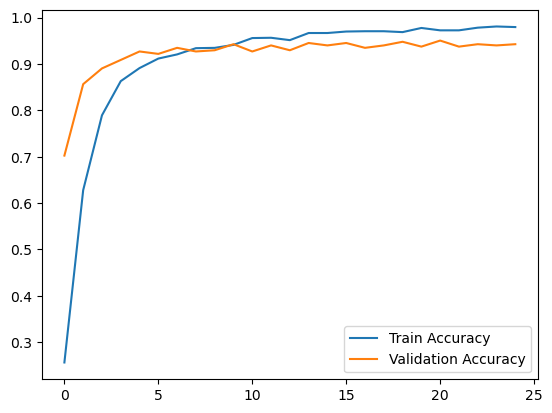

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [10]:
model.save("animal_classifier_efficientnet.h5")

In [11]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("animal_classifier_efficientnet.h5")

In [12]:
class_indices = train_generator.class_indices
class_labels = dict((v, k) for k, v in class_indices.items())

print(class_labels)

{0: 'Bear', 1: 'Bird', 2: 'Cat', 3: 'Cow', 4: 'Deer', 5: 'Dog', 6: 'Dolphin', 7: 'Elephant', 8: 'Giraffe', 9: 'Horse', 10: 'Kangaroo', 11: 'Lion', 12: 'Panda', 13: 'Tiger', 14: 'Zebra'}


In [13]:
import matplotlib.pyplot as plt

def predict_and_show(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)

    plt.title(f"Predicted: {class_labels[predicted_class]}")
    plt.show()

Enter image path:  C:\\Users\\Arnav\\Downloads\\Animal Classification\\dataset\\Lion\\Lion_3_2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


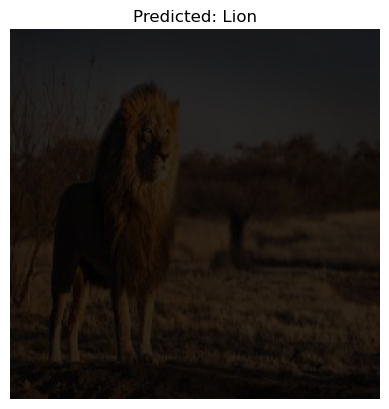

In [21]:
img_path = input("Enter image path: ")
predict_and_show(img_path)

In [15]:
final_val_accuracy = history.history['val_accuracy'][-1]
print(f"Final Validation Accuracy: {final_val_accuracy * 100:.2f}%")

Final Validation Accuracy: 94.26%


In [16]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.9504 - loss: 0.1744  
Validation Accuracy: 95.04%


In [17]:
loss, accuracy = model.evaluate(val_generator)
print(f"Fine-Tuned Model Accuracy: {accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9556 - loss: 0.1929
Fine-Tuned Model Accuracy: 95.56%
